In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

import nltk

In [30]:
df = pd.read_csv('reviews.csv')

In [31]:
df.head()

,Index,Name,Overall_Rating,Cuisine,Rate for two,City,Review
0,0,Oliver Brown,3.9,"Cafe, Coffee, Shake, Juices, Beverages, Waffle...",500,ahmedabad,Been to this place 3-4 times. Prakash is alway...
1,1,Oliver Brown,3.9,"Cafe, Coffee, Shake, Juices, Beverages, Waffle...",500,ahmedabad,I recently visited Oliver Brown on a weekend f...
2,2,Crush Coffee,3,"Cafe, Shake, Beverages, Desserts",600,ahmedabad,Very watery ans thin shake
3,3,The Mohalla,3.8,Cafe,550,ahmedabad,it was not cheese burst pizza.. only cheeze wa...
4,4,The Mohalla,3.8,Cafe,550,ahmedabad,"Yammi.,....test burger is best I love 💗 this B..."


In [32]:
df['Review'].values[0]

'Been to this place 3-4 times. Prakash is always very sweet and accommodating. Plus always ask Vaibhav to make your shakes, they are perfect!!'

In [33]:
df = df.head(500)
print(df.shape)

(500, 7)


EDA


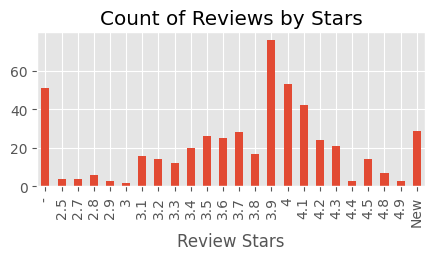

In [34]:
ax = df['Overall_Rating'].value_counts().sort_index() \
    .plot(kind='bar',
          title='Count of Reviews by Stars',
          figsize=(5, 2))
ax.set_xlabel('Review Stars')
plt.show()

NLTK


In [35]:
example= df['Review'][32]
print(example)

really poor food quality.... totally waste of money .I'll never suggest this to anyone 


In [36]:
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [37]:
import nltk
nltk.download('punkt_tab')
tokens = nltk.word_tokenize(example)
tokens[:10]

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


['really',
 'poor',
 'food',
 'quality',
 '....',
 'totally',
 'waste',
 'of',
 'money',
 '.I']

In [38]:
import nltk
nltk.download('averaged_perceptron_tagger_eng')
tagged = nltk.pos_tag(tokens)
tagged[:10]

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


[('really', 'RB'),
 ('poor', 'JJ'),
 ('food', 'NN'),
 ('quality', 'NN'),
 ('....', 'NNP'),
 ('totally', 'RB'),
 ('waste', 'NN'),
 ('of', 'IN'),
 ('money', 'NN'),
 ('.I', 'NN')]

In [39]:
import nltk
nltk.download('maxent_ne_chunker_tab')
nltk.download('words')
entities = nltk.chunk.ne_chunk(tagged)
entities.pprint()

[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package maxent_ne_chunker_tab is already up-to-date!
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Package words is already up-to-date!


(S
  really/RB
  poor/JJ
  food/NN
  quality/NN
  ..../NNP
  totally/RB
  waste/NN
  of/IN
  money/NN
  .I/NN
  'll/MD
  never/RB
  suggest/VB
  this/DT
  to/TO
  anyone/NN)


VADER

In [40]:
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
from tqdm.notebook import tqdm

nltk.download('vader_lexicon')
sia = SentimentIntensityAnalyzer()

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [41]:
sia.polarity_scores('It is a lovely day!')

{'neg': 0.0, 'neu': 0.423, 'pos': 0.577, 'compound': 0.6239}

In [42]:
sia.polarity_scores('This is the worst thing ever.')

{'neg': 0.451, 'neu': 0.549, 'pos': 0.0, 'compound': -0.6249}

In [43]:
sia.polarity_scores(example)

{'neg': 0.351, 'neu': 0.649, 'pos': 0.0, 'compound': -0.7569}

In [44]:
# Run the polarity score on the entire dataset
res = {}
for i, row in tqdm(df.iterrows(), total=len(df)):
    text = row['Review']
    myid = row['Index']
    res[myid] = sia.polarity_scores(text)

  0%|          | 0/500 [00:00<?, ?it/s]

In [45]:
vaders = pd.DataFrame(res).T
vaders = vaders.reset_index().rename(columns={'index': 'Index'})
vaders = vaders.merge(df, how='left')

In [46]:
vaders.head()

,Index,neg,neu,pos,compound,Name,Overall_Rating,Cuisine,Rate for two,City,Review
0,0,0.000,0.744,0.256,0.8214,Oliver Brown,3.9,"Cafe, Coffee, Shake, Juices, Beverages, Waffle...",500,ahmedabad,Been to this place 3-4 times. Prakash is alway...
1,1,0.000,0.718,0.282,0.9656,Oliver Brown,3.9,"Cafe, Coffee, Shake, Juices, Beverages, Waffle...",500,ahmedabad,I recently visited Oliver Brown on a weekend f...
2,2,0.298,0.702,0.000,-0.1779,Crush Coffee,3,"Cafe, Shake, Beverages, Desserts",600,ahmedabad,Very watery ans thin shake
3,3,0.136,0.864,0.000,-0.4585,The Mohalla,3.8,Cafe,550,ahmedabad,it was not cheese burst pizza.. only cheeze wa...
4,4,0.097,0.531,0.372,0.8020,The Mohalla,3.8,Cafe,550,ahmedabad,"Yammi.,....test burger is best I love 💗 this B..."


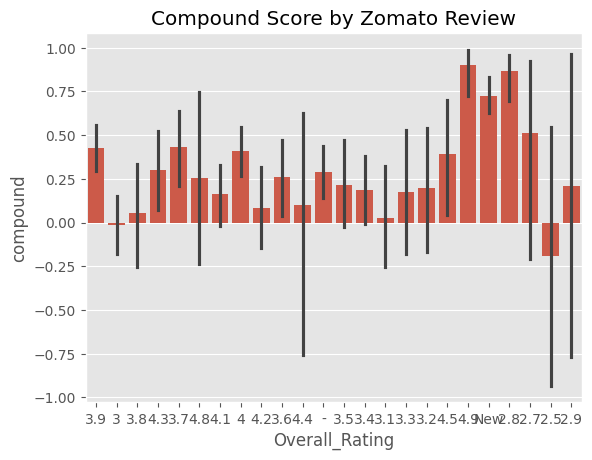

In [47]:
ax = sns.barplot(data=vaders, x='Overall_Rating', y='compound')
ax.set_title('Compound Score by Zomato Review')
plt.show()

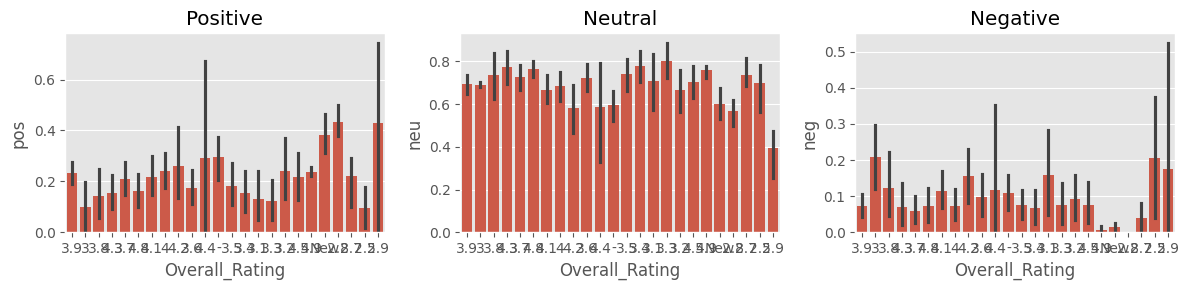

In [48]:
fig, axs = plt.subplots(1, 3, figsize=(12, 3))
sns.barplot(data=vaders, x='Overall_Rating', y='pos', ax=axs[0])
sns.barplot(data=vaders, x='Overall_Rating', y='neu', ax=axs[1])
sns.barplot(data=vaders, x='Overall_Rating', y='neg', ax=axs[2])
axs[0].set_title('Positive')
axs[1].set_title('Neutral')
axs[2].set_title('Negative')
plt.tight_layout()
plt.show()

robert pretained model


In [49]:
from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification
from scipy.special import softmax

In [50]:
MODEL = f"cardiffnlp/twitter-roberta-base-sentiment"
tokenizer = AutoTokenizer.from_pretrained(MODEL)
model = AutoModelForSequenceClassification.from_pretrained(MODEL)

In [51]:
print(example)
sia.polarity_scores(example)

really poor food quality.... totally waste of money .I'll never suggest this to anyone 


{'neg': 0.351, 'neu': 0.649, 'pos': 0.0, 'compound': -0.7569}

In [52]:
encoded_text = tokenizer(example, return_tensors='pt')
output = model(**encoded_text)
ratings = output[0][0].detach().numpy()
ratings = softmax(ratings)
ratings_dict = {
    'roberta_neg' : ratings[0],
    'roberta_neu' : ratings[1],
    'roberta_pos' : ratings[2]
}
print(ratings_dict)

{'roberta_neg': np.float32(0.9632064), 'roberta_neu': np.float32(0.032082096), 'roberta_pos': np.float32(0.0047115856)}


In [53]:
def polarity_scores_roberta(example):
    encoded_text = tokenizer(example, return_tensors='pt')
    output = model(**encoded_text)
    ratings = output[0][0].detach().numpy()
    ratings = softmax(ratings)
    ratings_dict = {
        'roberta_neg' : ratings[0],
        'roberta_neu' : ratings[1],
        'roberta_pos' : ratings[2]
    }
    return ratings_dict

In [54]:
res = {}
for i, row in tqdm(df.iterrows(), total=len(df)):
    text = row['Review']
    myid = row['Index']
    vader_result = sia.polarity_scores(text)

    vader_result_rename = {}
    for key, value in vader_result.items():
          vader_result_rename[f"vader_{key}"] = value


    roberta_result = polarity_scores_roberta(text)
    both = {**vader_result, **roberta_result}
    res[myid] = both


  0%|          | 0/500 [00:00<?, ?it/s]

In [57]:
results_df = pd.DataFrame(res).T
results_df = results_df.reset_index().rename(columns={'index': 'Index'})
results_df = results_df.merge(df, how='left')

In [58]:
results_df.columns

Index(['Index', 'neg', 'neu', 'pos', 'compound', 'roberta_neg', 'roberta_neu',
       'roberta_pos', 'Name', 'Overall_Rating', 'Cuisine', 'Rate for two',
       'City', 'Review'],
      dtype='object')

combining and comparing

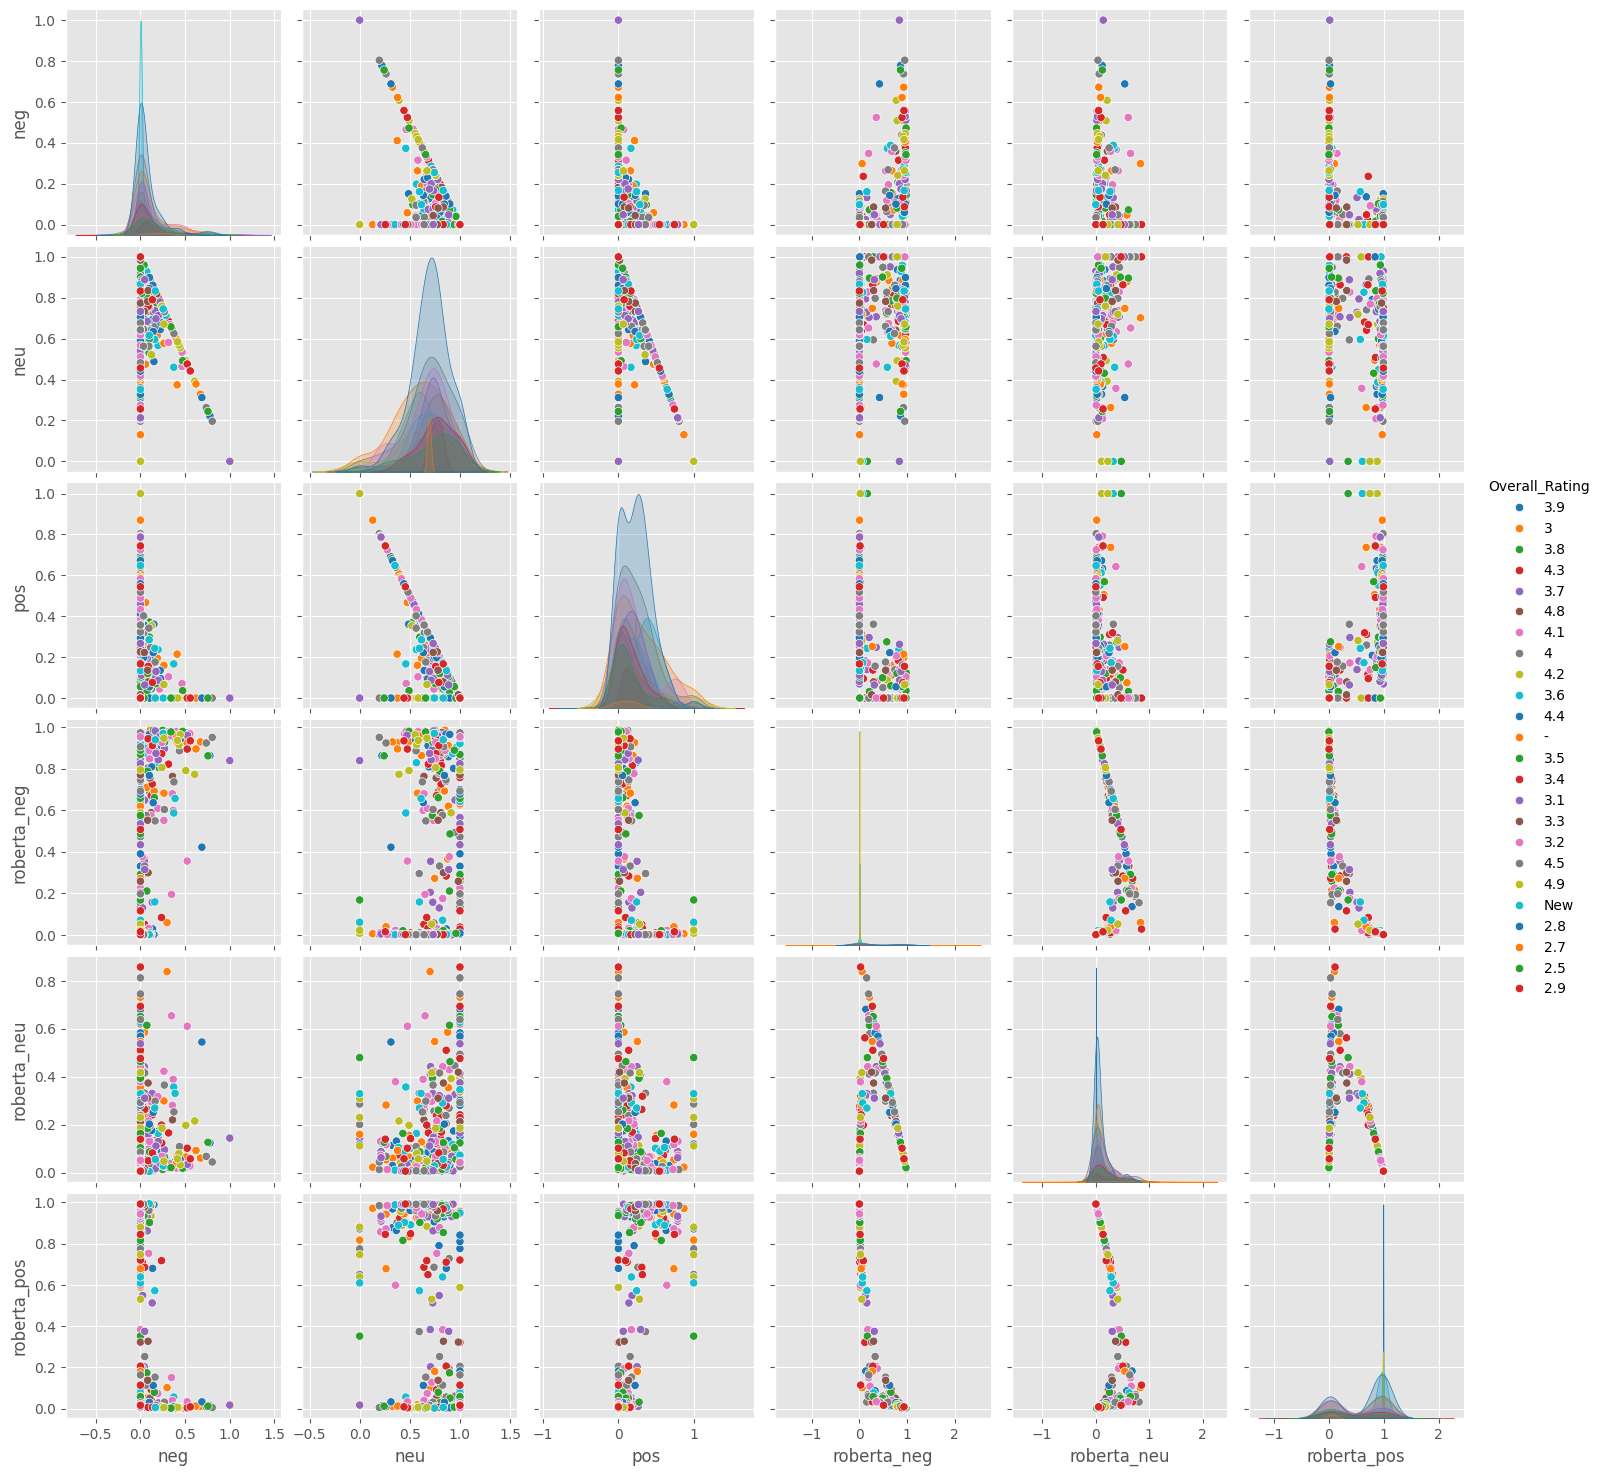

In [60]:
sns.pairplot(data=results_df,
             vars=['neg', 'neu', 'pos',
                  'roberta_neg', 'roberta_neu', 'roberta_pos'],
            hue='Overall_Rating',
            palette='tab10')
plt.show()

Review Examples


In [69]:
results_df.query('Overall_Rating_numeric == 3.9') \
    .sort_values('roberta_pos', ascending=False)['Review'].iloc[0]

"I recently visited Oliver Brown on a weekend for a cup of iced coffee, and I was thoroughly impressed. The ambience was inviting, the seating comfortable, and the service top-notch. I had the pleasure of trying their iced coffee and dark hot chocolate, both of which were absolutely delicious. It's an excellent place overall, and I'm already looking forward to my next visit"

In [71]:
results_df.query('Overall_Rating_numeric == 3.9') \
    .sort_values('pos', ascending=False)['Review'].iloc[0]

'Delicious'

In [72]:
results_df.query('Overall_Rating_numeric == 4.1') \
    .sort_values('roberta_neg', ascending=False)['Review'].iloc[0]

'Worst ambiance, no ac or fan. the service is also very bad. the satff is rude and ruthless. Dont visit please'

In [74]:
results_df.query('Overall_Rating_numeric == 4.1') \
    .sort_values('neg', ascending=False)['Review'].iloc[0]

'no soya in soya chilli. pathetic food. waste of money.'